In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from skimage.exposure import match_histograms
import matplotlib.pyplot as plt

In [2]:
BASE_PATH = Path(r"E:\Thesis")

HAM_DIR = BASE_PATH / "HAM10000" / "images"
PAD_DIR = BASE_PATH / "PAD-UFES-20" / "images"
PAD_META = BASE_PATH / "PAD-UFES-20" / "metadata.csv"

OUTPUT_DIR = BASE_PATH / "PAD_HIST_MATCH_IMPROVED"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("HAM:", HAM_DIR)
print("PAD:", PAD_DIR)
print("OUT:", OUTPUT_DIR)

HAM: E:\Thesis\HAM10000\images
PAD: E:\Thesis\PAD-UFES-20\images
OUT: E:\Thesis\PAD_HIST_MATCH_IMPROVED


In [3]:
pad_df = pd.read_csv(PAD_META)

# keep your 4 classes only
pad_df = pad_df[pad_df["diagnostic"].isin(["ACK", "BCC", "MEL", "NEV"])].copy()
pad_df["label"] = pad_df["diagnostic"]
pad_df["image_path"] = pad_df["img_id"].apply(lambda x: str(PAD_DIR / x))

pad_df = pad_df[pad_df["image_path"].apply(os.path.exists)].copy()
print("PAD samples:", len(pad_df))
print(pad_df["label"].value_counts())

PAD samples: 1871
label
BCC    845
ACK    730
NEV    244
MEL     52
Name: count, dtype: int64


In [4]:
def image_stats_for_ref(path):
    img = cv2.imread(str(path))
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)

    r = img[:, :, 0].mean()
    g = img[:, :, 1].mean()
    b = img[:, :, 2].mean()
    lum = 0.299 * img[:, :, 0] + 0.587 * img[:, :, 1] + 0.114 * img[:, :, 2]
    brightness = lum.mean()
    contrast = lum.std()
    return np.array([r, g, b, brightness, contrast], dtype=np.float32)

ham_files = sorted([p for p in HAM_DIR.glob("*") if p.suffix.lower() in [".jpg", ".jpeg", ".png"]])
print("HAM images found:", len(ham_files))

# sample if too many, but enough for representative selection
sample_size = min(1000, len(ham_files))
sample_files = np.random.RandomState(42).choice(ham_files, size=sample_size, replace=False)

stats_list = []
valid_files = []

for p in tqdm(sample_files, desc="Computing HAM stats"):
    s = image_stats_for_ref(p)
    if s is not None:
        stats_list.append(s)
        valid_files.append(p)

stats_arr = np.vstack(stats_list)

centroid = stats_arr.mean(axis=0)
dists = np.linalg.norm(stats_arr - centroid, axis=1)

ref_idx = int(np.argmin(dists))
reference_path = valid_files[ref_idx]

print("Selected reference:", reference_path.name)

HAM images found: 10015


Computing HAM stats: 100%|██████████| 1000/1000 [00:46<00:00, 21.68it/s]

Selected reference: ISIC_0032455.jpg


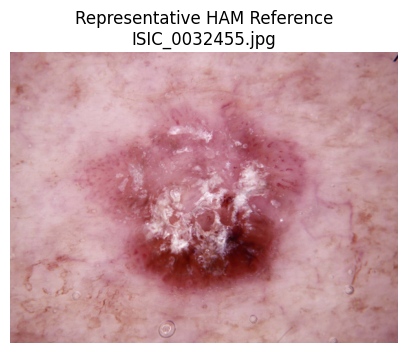

In [5]:
reference = cv2.imread(str(reference_path))
reference = cv2.cvtColor(reference, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(reference)
plt.title(f"Representative HAM Reference\n{reference_path.name}")
plt.axis("off")
plt.show()

In [6]:
def hist_match_image(img_rgb, ref_rgb):
    matched = match_histograms(img_rgb, ref_rgb, channel_axis=-1)
    matched = np.clip(matched, 0, 255).astype(np.uint8)
    return matched

In [7]:
for _, row in tqdm(pad_df.iterrows(), total=len(pad_df), desc="Histogram matching PAD"):
    img_path = Path(row["image_path"])
    img = cv2.imread(str(img_path))
    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    matched = hist_match_image(img, reference)

    save_path = OUTPUT_DIR / img_path.name
    cv2.imwrite(str(save_path), cv2.cvtColor(matched, cv2.COLOR_RGB2BGR))

Histogram matching PAD: 100%|██████████| 1871/1871 [09:30<00:00,  3.28it/s]


In [8]:
matched_df = pad_df.copy()
matched_df["image_path"] = matched_df["img_id"].apply(lambda x: str(OUTPUT_DIR / x))

matched_df.to_csv(OUTPUT_DIR / "pad_hist_matched_paths.csv", index=False)
print("Saved:", OUTPUT_DIR / "pad_hist_matched_paths.csv")
print("Matched images:", len(matched_df))

Saved: E:\Thesis\PAD_HIST_MATCH_IMPROVED\pad_hist_matched_paths.csv
Matched images: 1871


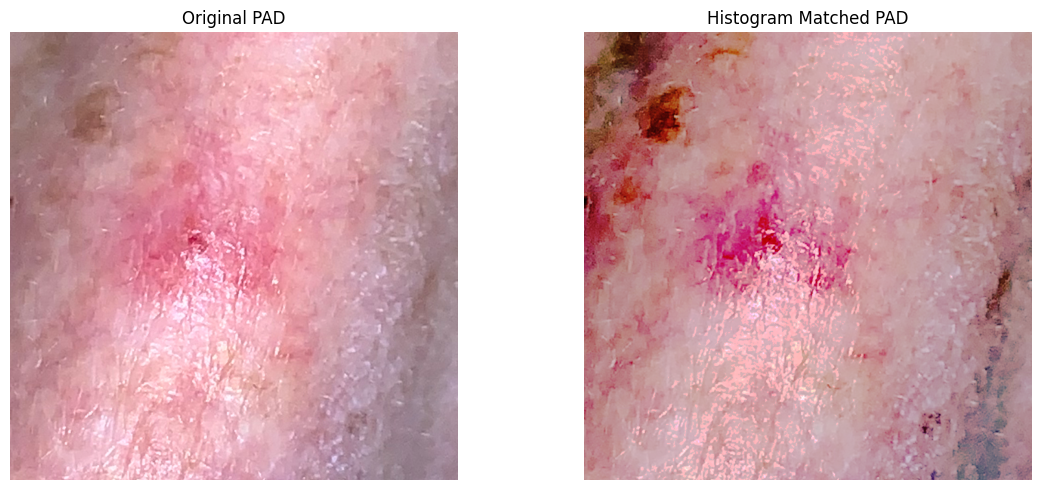

In [9]:
idx = 10 if len(pad_df) > 10 else 0
orig_path = Path(pad_df.iloc[idx]["image_path"])
matched_path = OUTPUT_DIR / orig_path.name

orig = cv2.cvtColor(cv2.imread(str(orig_path)), cv2.COLOR_BGR2RGB)
matc = cv2.cvtColor(cv2.imread(str(matched_path)), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(orig)
plt.title("Original PAD")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(matc)
plt.title("Histogram Matched PAD")
plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# তোমার histogram matched folder
HIST_DIR = Path(r"E:\Thesis\PAD_HIST_MATCH_IMPROVED")

pad_hist_df = pad_df.copy()
pad_hist_df["image_path"] = pad_hist_df["image_path"].apply(
    lambda x: str(HIST_DIR / Path(x).name)
)

pad_hist_df.head()

,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,...,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed,label,image_path
0,PAT_1516,1765,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,...,False,False,False,False,False,False,PAT_1516_1765_530.png,False,NEV,E:\Thesis\PAD_HIST_MATCH_IMPROVED\PAT_1516_176...
1,PAT_46,881,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,...,True,True,False,True,True,True,PAT_46_881_939.png,True,BCC,E:\Thesis\PAD_HIST_MATCH_IMPROVED\PAT_46_881_9...
2,PAT_1545,1867,NaN,NaN,NaN,NaN,77,NaN,NaN,NaN,...,True,False,False,False,False,False,PAT_1545_1867_547.png,False,ACK,E:\Thesis\PAD_HIST_MATCH_IMPROVED\PAT_1545_186...
3,PAT_1989,4061,NaN,NaN,NaN,NaN,75,NaN,NaN,NaN,...,True,False,False,False,False,False,PAT_1989_4061_934.png,False,ACK,E:\Thesis\PAD_HIST_MATCH_IMPROVED\PAT_1989_406...
4,PAT_684,1302,False,True,POMERANIA,POMERANIA,79,False,MALE,True,...,True,True,False,False,True,True,PAT_684_1302_588.png,True,BCC,E:\Thesis\PAD_HIST_MATCH_IMPROVED\PAT_684_1302...


In [14]:
missing = pad_hist_df[~pad_hist_df["image_path"].apply(os.path.exists)]

print("Missing images:", len(missing))
if len(missing) > 0:
    print(missing.head())

Missing images: 0


In [21]:
import os
from pathlib import Path
import pandas as pd

BASE_PATH = Path(r"E:\Thesis")
PAD_PATH = BASE_PATH / "PAD-UFES-20"
PAD_DIR = PAD_PATH / "images"
PAD_META = PAD_PATH / "metadata.csv"

print("PAD_PATH exists:", PAD_PATH.exists())
print("PAD_DIR exists:", PAD_DIR.exists())
print("PAD_META exists:", PAD_META.exists())

pad = pd.read_csv(PAD_META)

pad_4 = pad[pad["diagnostic"].isin(["ACK", "BCC", "MEL", "NEV"])].copy()
pad_4["label"] = pad_4["diagnostic"]
pad_4["image_path"] = pad_4["img_id"].apply(lambda x: str(PAD_DIR / x))
pad_4 = pad_4[pad_4["image_path"].apply(os.path.exists)].copy()

print("PAD_4 samples:", len(pad_4))
print(pad_4["label"].value_counts())

PAD_PATH exists: True
PAD_DIR exists: True
PAD_META exists: True
PAD_4 samples: 1871
label
BCC    845
ACK    730
NEV    244
MEL     52
Name: count, dtype: int64


In [22]:
from pathlib import Path
import os

HIST_DIR = Path(r"E:\Thesis\PAD_HIST_MATCH_IMPROVED")

pad_hist_df = pad_4.copy()
pad_hist_df["image_path"] = pad_hist_df["img_id"].apply(lambda x: str(HIST_DIR / x))
pad_hist_df["exists"] = pad_hist_df["image_path"].apply(os.path.exists)

print("Histogram matched PAD exists:")
print(pad_hist_df["exists"].value_counts())
print("Histogram matched PAD labels:")
print(pad_hist_df["label"].value_counts())

Histogram matched PAD exists:
exists
True    1871
Name: count, dtype: int64
Histogram matched PAD labels:
label
BCC    845
ACK    730
NEV    244
MEL     52
Name: count, dtype: int64


In [23]:
missing = pad_hist_df[~pad_hist_df["exists"]]
print("Missing images:", len(missing))

Missing images: 0


In [24]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import preprocess_input

pad_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [26]:
IMG_SIZE = (250, 250)
BATCH_SIZE = 4
CLASS_NAMES = ["ACK", "BCC", "MEL", "NEV"]

In [27]:
pad_hist_generator = pad_datagen.flow_from_dataframe(
    dataframe=pad_hist_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

print("Histogram matched PAD samples:", pad_hist_generator.samples)

Found 1871 validated image filenames belonging to 4 classes.
Histogram matched PAD samples: 1871


In [28]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import preprocess_input

pad_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [29]:
import numpy as np
import pandas as pd
import os
from pathlib import Path

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import preprocess_input

IMG_SIZE = (250, 250)
BATCH_SIZE = 4
CLASS_NAMES = ["ACK", "BCC", "MEL", "NEV"]

pad_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [30]:
pad_hist_generator = pad_datagen.flow_from_dataframe(
    dataframe=pad_hist_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

print("Histogram matched PAD samples:", pad_hist_generator.samples)

Found 1871 validated image filenames belonging to 4 classes.
Histogram matched PAD samples: 1871


In [32]:
from pathlib import Path
import tensorflow as tf

BASE_PATH = Path(r"E:\Thesis")
OUT_DIR = BASE_PATH / "outputs" / "densenet201_baseline"

print("OUT_DIR exists:", OUT_DIR.exists())
print(OUT_DIR)

OUT_DIR exists: True
E:\Thesis\outputs\densenet201_baseline


In [33]:
best_model = tf.keras.models.load_model(OUT_DIR / "best_model.keras")
print("Best model loaded.")

Best model loaded.


In [35]:
hist_pad_loss, hist_pad_accuracy = best_model.evaluate(pad_hist_generator, verbose=1)
print("Histogram Matched PAD Accuracy:", hist_pad_accuracy)
print("Histogram Matched PAD Loss:", hist_pad_loss)

468/468 [==============================] - 159s 296ms/step - loss: 1.7801 - accuracy: 0.4645
Histogram Matched PAD Accuracy: 0.46445751190185547
Histogram Matched PAD Loss: 1.7801218032836914


In [37]:
import os
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import CSVLogger, ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)
from tensorflow.keras.utils import to_categorical

In [38]:
BASE_PATH = Path(r"E:\Thesis")

HAM_PATH = BASE_PATH / "HAM10000"
PAD_PATH = BASE_PATH / "PAD-UFES-20"

HAM_IMAGE_DIR = HAM_PATH / "images"
PAD_IMAGE_DIR = PAD_PATH / "images"

OUT_DIR = BASE_PATH / "outputs" / "densenet201_baseline"
HIST_DIR = BASE_PATH / "PAD_HIST_MATCH_IMPROVED"

IMG_SIZE = (250, 250)
BATCH_SIZE = 4
EPOCHS = 20

CLASS_NAMES = ["ACK", "BCC", "MEL", "NEV"]

print("HAM_PATH exists:", HAM_PATH.exists())
print("PAD_PATH exists:", PAD_PATH.exists())
print("OUT_DIR exists:", OUT_DIR.exists())
print("HIST_DIR exists:", HIST_DIR.exists())

HAM_PATH exists: True
PAD_PATH exists: True
OUT_DIR exists: True
HIST_DIR exists: True


In [39]:
pad = pd.read_csv(PAD_PATH / "metadata.csv")

pad_4 = pad[pad["diagnostic"].isin(CLASS_NAMES)].copy()
pad_4["label"] = pad_4["diagnostic"]
pad_4["image_path"] = pad_4["img_id"].apply(lambda x: str(PAD_IMAGE_DIR / x))
pad_4 = pad_4[pad_4["image_path"].apply(os.path.exists)].copy()

print("PAD_4 samples:", len(pad_4))
print(pad_4["label"].value_counts())

PAD_4 samples: 1871
label
BCC    845
ACK    730
NEV    244
MEL     52
Name: count, dtype: int64


In [40]:
pad_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

pad_generator = pad_datagen.flow_from_dataframe(
    dataframe=pad_4,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

print("PAD samples:", pad_generator.samples)

Found 1871 validated image filenames belonging to 4 classes.
PAD samples: 1871


In [41]:
pad_hist_df = pad_4.copy()
pad_hist_df["image_path"] = pad_hist_df["img_id"].apply(lambda x: str(HIST_DIR / x))
pad_hist_df["exists"] = pad_hist_df["image_path"].apply(os.path.exists)

print("Histogram matched files existing:")
print(pad_hist_df["exists"].value_counts())

Histogram matched files existing:
exists
True    1871
Name: count, dtype: int64


In [42]:
pad_hist_df = pad_hist_df[pad_hist_df["exists"]].copy()

pad_hist_generator = pad_datagen.flow_from_dataframe(
    dataframe=pad_hist_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

print("Histogram matched PAD samples:", pad_hist_generator.samples)

Found 1871 validated image filenames belonging to 4 classes.
Histogram matched PAD samples: 1871


In [43]:
best_model = tf.keras.models.load_model(OUT_DIR / "best_model.keras")
print("Best model loaded.")

Best model loaded.


In [44]:
orig_pad_loss, orig_pad_accuracy = best_model.evaluate(pad_generator, verbose=1)
print("Original PAD Accuracy:", orig_pad_accuracy)
print("Original PAD Loss:", orig_pad_loss)

468/468 [==============================] - 68s 137ms/step - loss: 3.0001 - accuracy: 0.2892
Original PAD Accuracy: 0.2891501784324646
Original PAD Loss: 3.0000996589660645


In [45]:
hist_pad_loss, hist_pad_accuracy = best_model.evaluate(pad_hist_generator, verbose=1)
print("Histogram Matched PAD Accuracy:", hist_pad_accuracy)
print("Histogram Matched PAD Loss:", hist_pad_loss)

468/468 [==============================] - 59s 124ms/step - loss: 1.7801 - accuracy: 0.4645
Histogram Matched PAD Accuracy: 0.46445751190185547
Histogram Matched PAD Loss: 1.7801218032836914


In [46]:
orig_pred_probs = best_model.predict(pad_generator, verbose=1)
orig_pred_classes = np.argmax(orig_pred_probs, axis=1)
orig_true_classes = pad_generator.classes

hist_pred_probs = best_model.predict(pad_hist_generator, verbose=1)
hist_pred_classes = np.argmax(hist_pred_probs, axis=1)
hist_true_classes = pad_hist_generator.classes

468/468 [==============================] - 59s 126ms/step


In [47]:
def compute_metrics(true_classes, pred_classes, pred_probs, class_names):
    acc = accuracy_score(true_classes, pred_classes)
    prec = precision_score(true_classes, pred_classes, average="macro", zero_division=0)
    rec = recall_score(true_classes, pred_classes, average="macro", zero_division=0)
    f1 = f1_score(true_classes, pred_classes, average="macro", zero_division=0)

    true_onehot = to_categorical(true_classes, num_classes=len(class_names))
    auc = roc_auc_score(
        true_onehot,
        pred_probs,
        multi_class="ovr",
        average="macro"
    )

    report = classification_report(
        true_classes,
        pred_classes,
        target_names=class_names,
        zero_division=0
    )

    cm = confusion_matrix(true_classes, pred_classes)

    return acc, prec, rec, f1, auc, report, cm

In [48]:
orig_acc, orig_prec, orig_rec, orig_f1, orig_auc, orig_report, orig_cm = compute_metrics(
    orig_true_classes,
    orig_pred_classes,
    orig_pred_probs,
    CLASS_NAMES
)

print("=== Original PAD ===")
print("Accuracy :", orig_acc)
print("Precision:", orig_prec)
print("Recall   :", orig_rec)
print("F1 Score :", orig_f1)
print("AUC      :", orig_auc)
print(orig_report)

=== Original PAD ===
Accuracy : 0.28915018706574025
Precision: 0.29792286744381263
Recall   : 0.34610476349299785
F1 Score : 0.21773694454600206
AUC      : 0.6664067795001829
              precision    recall  f1-score   support

         ACK       0.28      0.03      0.06       730
         BCC       0.68      0.34      0.45       845
         MEL       0.05      0.08      0.06        52
         NEV       0.18      0.94      0.30       244

    accuracy                           0.29      1871
   macro avg       0.30      0.35      0.22      1871
weighted avg       0.44      0.29      0.27      1871



In [49]:
hist_acc, hist_prec, hist_rec, hist_f1, hist_auc, hist_report, hist_cm = compute_metrics(
    hist_true_classes,
    hist_pred_classes,
    hist_pred_probs,
    CLASS_NAMES
)

print("=== Histogram Matched PAD ===")
print("Accuracy :", hist_acc)
print("Precision:", hist_prec)
print("Recall   :", hist_rec)
print("F1 Score :", hist_f1)
print("AUC      :", hist_auc)
print(hist_report)

=== Histogram Matched PAD ===
Accuracy : 0.464457509353287
Precision: 0.37370749445391666
Recall   : 0.45669884473867095
F1 Score : 0.38161322120910757
AUC      : 0.6754206677007579
              precision    recall  f1-score   support

         ACK       0.31      0.07      0.12       730
         BCC       0.50      0.76      0.60       845
         MEL       0.18      0.35      0.23        52
         NEV       0.51      0.65      0.57       244

    accuracy                           0.46      1871
   macro avg       0.37      0.46      0.38      1871
weighted avg       0.42      0.46      0.40      1871



In [50]:
comparison = pd.DataFrame({
    "Setting": ["Original PAD", "Histogram Matched PAD"],
    "Accuracy": [orig_acc, hist_acc],
    "Macro Precision": [orig_prec, hist_prec],
    "Macro Recall": [orig_rec, hist_rec],
    "Macro F1": [orig_f1, hist_f1],
    "Macro AUC": [orig_auc, hist_auc]
})

comparison["Accuracy Gain"] = comparison["Accuracy"] - comparison.loc[0, "Accuracy"]
comparison["F1 Gain"] = comparison["Macro F1"] - comparison.loc[0, "Macro F1"]
comparison["AUC Gain"] = comparison["Macro AUC"] - comparison.loc[0, "Macro AUC"]

print(comparison)

                 Setting  Accuracy  Macro Precision  Macro Recall  Macro F1  \
0           Original PAD  0.289150         0.297923      0.346105  0.217737   
1  Histogram Matched PAD  0.464458         0.373707      0.456699  0.381613   

   Macro AUC  Accuracy Gain   F1 Gain  AUC Gain  
0   0.666407       0.000000  0.000000  0.000000  
1   0.675421       0.175307  0.163876  0.009014  


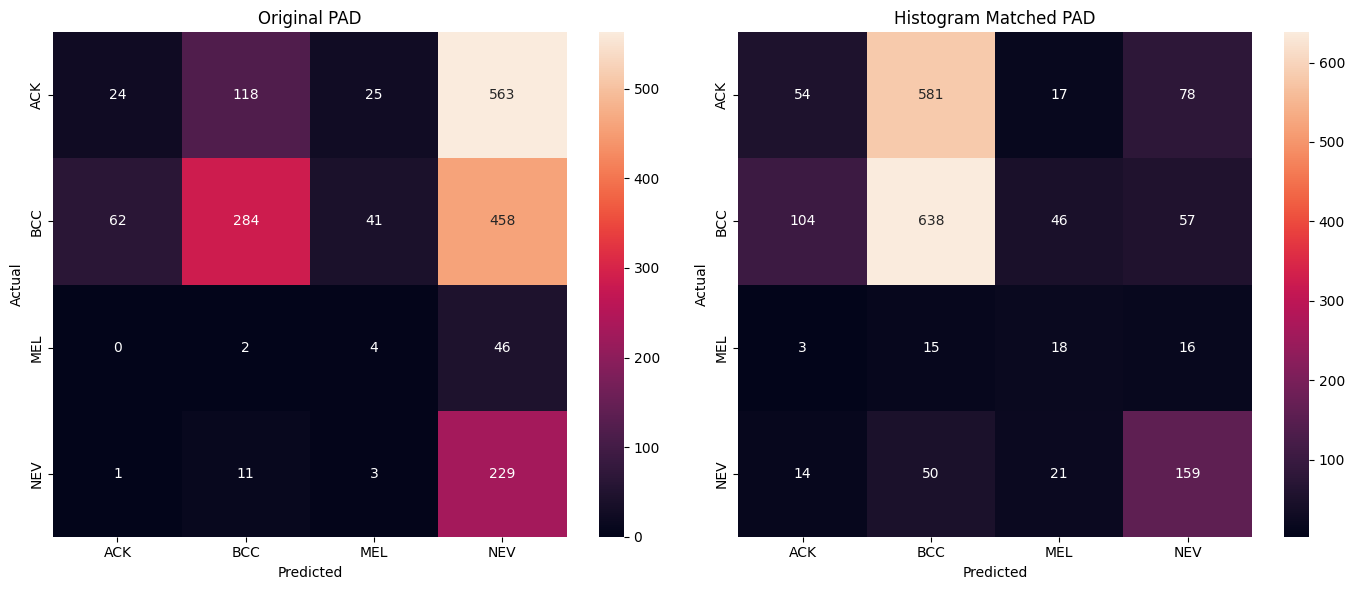

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(orig_cm, annot=True, fmt="d", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("Original PAD")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(hist_cm, annot=True, fmt="d", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title("Histogram Matched PAD")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()